# Importação das bibliotecas necessárias do ecossistema Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal  

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Modelagem do Sistema Físico (Motor DC simplificado)

In [ ]:
K_motor = 2.0    # Ganho estático do motor
tau_motor = 0.5  # Constante de tempo do motor (segundos)
    
num_planta = [K_motor]
den_planta = [tau_motor, 1.0]
planta = signal.TransferFunction(num_planta, den_planta) 

TransferFunctionContinuous(
array([4.]),
array([1., 2.]),
dt: None
)

 # 2. Projeto do Controlador PID (Implementação análoga à de um CLP)

In [3]:
Kp = 1.5
Ki = 2.0
Kd = 0.1
    
num_pid = [Kd, Kp, Ki]
den_pid = [1, 0]
controlador = signal.TransferFunction(num_pid, den_pid)

 # 3. Malha Fechada: H(s) = (C(s)*G(s)) / (1 + C(s)*G(s))

In [4]:
num_malha_aberta = np.convolve(num_pid, num_planta)
den_malha_aberta = np.convolve(den_pid, den_planta)
    
    # Fechando a malha unitária
num_malha_fechada = num_malha_aberta
den_malha_fechada = np.polyadd(den_malha_aberta, num_malha_aberta)
    
sistema_malha_fechada = signal.TransferFunction(num_malha_fechada, den_malha_fechada)

 # 4. Simulação da Resposta ao Degrau (Setpoint de Velocidade da IHM)

In [5]:
t = np.linspace(0, 5, 500)
# Simulando um degrau unitário aplicado pelo operador
tempo, resposta = signal.step(sistema_malha_fechada, T=t)
    

# 5. Visualização dos Resultados

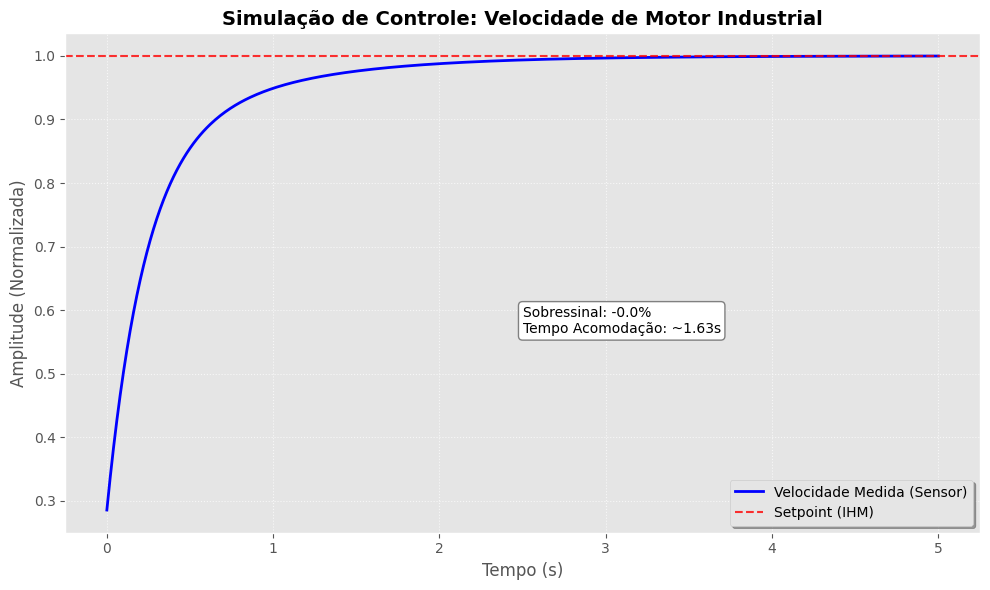

In [6]:

fig, ax = plt.subplots(tight_layout=True)
    
ax.plot(tempo, resposta, label='Velocidade Medida (Sensor)', color='blue', linewidth=2)
ax.axhline(y=1.0, color='red', linestyle='--', label='Setpoint (IHM)', alpha=0.8)
    
# Análise de métricas de controle
sobressinal = max(resposta) - 1.0
tempo_acomodacao = tempo[np.where(np.abs(resposta - 1.0) < 0.02)[0][0]] if len(np.where(np.abs(resposta - 1.0) < 0.02)[0]) > 0 else t[-1]

ax.annotate(f'Sobressinal: {sobressinal*100:.1f}%\nTempo Acomodação: ~{tempo_acomodacao:.2f}s', 
                xy=(0.5, 0.4), xycoords='axes fraction', 
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1))

ax.set_title('Simulação de Controle: Velocidade de Motor Industrial', fontsize=14, fontweight='bold')
ax.set_xlabel('Tempo (s)', fontsize=12)
ax.set_ylabel('Amplitude (Normalizada)', fontsize=12)
ax.legend(loc='lower right', shadow=True)
ax.grid(True, linestyle=':', alpha=0.7)
    
plt.show()